# Set Up

## Libraries

In [3]:
import sys
sys.path.append(r"C:\GitHubRepos\APSIMTools\GraphLib")

%load_ext autoreload
%autoreload 2

from dataclasses import dataclass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sqlite3
import subprocess
import shutil
import warnings
from matplotlib.lines import Line2D
from pandas.api.types import is_numeric_dtype


# graph models
from apsim_tools.graphing import (
    plot_obs_pred_by_branch,
    plot_stage_timeseries,
    compute_stats
)

from apsim_tools.style import ( 
    Colors, 
    Markers,
    Lines
)

from apsim_tools.runner import (
reset_repo,
checkout_branch,
build_apsim,
run_apsim
)



## Grouping functions

In [4]:
def value_at_stage(target, tol_low, tol_high):

    def fn(df, variable):

        window = df.loc[
            (df["Wheat.Phenology.Stage"] > tol_low) &
            (df["Wheat.Phenology.Stage"] < tol_high)
        ]

        window = window[window[variable].notna()]

        if window.empty:
            return np.nan

        idx = (
            window["Wheat.Phenology.Stage"]
            .sub(target)
            .abs()
            .idxmin()
        )

        return window.loc[idx, variable]

    return fn

def MeanValue(df, variable):
    return df[variable].mean()

def SumValues(df, variable):
    return df[variable].sum()

## data class

In [5]:
@dataclass
class AnalysisData:

    pred: pd.DataFrame
    obs: pd.DataFrame
    harvest_pred: pd.DataFrame
    harvest_obs: pd.DataFrame

    def derive(self, name, fn):

        derived = fn(self.obs)
    
        if not isinstance(derived, pd.Series):
            derived = pd.Series(
                derived,
                index=self.obs.index)
    
        if name in self.obs.columns:
            self.obs[name] = (
                self.obs[name]
                .combine_first(derived))
    
        else:
            self.obs[name] = derived

    def filter(self, fn):

        filterMask = fn(self.obs)

        return filterMask

    def fill_triangular_set(self, top, left, right):

        cols = [top, left, right]
    
        missing = [c for c in cols if c not in self.obs.columns]
    
        if missing:
            print(f"Missing columns: {missing}")
            return self
    
        a = self.obs[top]
        b = self.obs[left]
        c = self.obs[right]
    
        # fill top
        self.obs[top] = a.combine_first(b * c)
    
        # fill left
        self.obs[left] = b.combine_first(
            a.div(c.replace(0, np.nan))
        )
    
        # fill right
        self.obs[right] = c.combine_first(
            a.div(b.replace(0, np.nan))
        )
        
    def aggregate_sim_values(self, var, outName, source="obs", fn = MeanValue, filter_fn = None):
        df = getattr(self, source)
        mask = pd.Series(True, index=df.index)
        if filter_fn:
            mask = filter_fn(df)
    
        grouped = (df.loc[mask].groupby("Simulation.Name"))
    
        values = grouped.apply(lambda g: fn(g, var))
    
        self.obs[outName] = (self.obs["Simulation.Name"].map(values))        

    def summary(self):
        print(f"Pred rows : {len(self.pred):,}")
        print(f"Obs rows  : {len(self.obs):,}")

        print(f"Pred sims : {self.pred['SimulationID'].nunique():,}")
        print(f"Obs sims  : {self.obs['SimulationID'].nunique():,}")


ANALYSIS_KEYS = [
    "file",
    "SimulationID",
    "Clock.Today"
]

## Load branch data function

In [6]:
def load_branch_data(config, apply_fn):
    pred_frames = []
    obs_frames = []
    for branch_name, git_branch in config["git_branches"].items():
        
        if branch_name in config['run_branches']:
            reset_repo(config)
            checkout_branch(git_branch, config)
            build_apsim(config)
    
        for sim in config["sim_files"]:
    
            db = sim.parent / f"{sim.stem}_{branch_name}.db"
    
            # --- Run APSIM ---
            if branch_name in config['run_branches']:
                print("")
                print(f"▶ Running APSIM [{branch_name}]: {sim.name}")
                run_apsim(sim, config, apply_fn)
    
                original_db = sim.with_suffix(".db")
                hold_db = sim.parent / f"{sim.stem}_{branch_name}.db"
    
                shutil.copyfile(original_db, hold_db)
    
            if not db.exists():
                print(f"❌ DB not created: {db}")
                continue
    
            # ======================================================
            # ✅ READ DATABASE
            # ======================================================
            with sqlite3.connect(db) as conn:
    
                tables = pd.read_sql(
                    "SELECT name FROM sqlite_master WHERE type='table';",
                    conn
                )["name"].tolist()
    
                print(f"{sim.name} tables: {tables}")
    
                # ---------------------------------------------
                # ✅ Observed
                # ---------------------------------------------
                obs = None
                if config["obs_table_name"] in tables and branch_name=="master":
                    obs = pd.read_sql(f"SELECT * FROM [{config['obs_table_name']}]", conn)
                    obs = obs.drop(columns=["SimulationName"], errors="ignore")
                    
                # ---------------------------------------------
                # ✅ Predictions
                # ---------------------------------------------
                pred = None
                if config["pred_table_name"] in tables:
                    pred = pd.read_sql(f"SELECT * FROM [{config['pred_table_name']}]", conn)
                    
                if pred is None and obs is None:
                    continue
                
                # ---------------------------------------------
                # ✅ Diagnose SimulationID alignment
                # ---------------------------------------------
                if pred is not None and obs is not None:
    
                    pred_ids = set(pred["SimulationID"].dropna().unique())
                    obs_ids = set(obs["SimulationID"].dropna().unique())
    
                    # --- Diagnostics (optional but useful) ---
                    missing_ids = pred_ids - obs_ids
                    if missing_ids:
                        print(f"\n⚠️ Missing observed simulations in {sim.name}: {len(missing_ids)}")
    
                    extra_obs_ids = obs_ids - pred_ids
                    if extra_obs_ids:
                        print(f"\n⚠️ Dropping unmatched observed simulations in {sim.name}: {len(extra_obs_ids)}")
    
                # ---------------------------------------------
                # ✅ Attach metadata (branch, file)
                # ---------------------------------------------
                if pred is not None:
                    pred["file"] = sim.name
                    pred["branch"] = branch_name
                    pred_frames.append(pred)
                    if "Clock.Today" in pred.columns:
                        pred["Clock.Today"] = pd.to_datetime(pred["Clock.Today"])
    
                if obs is not None:
                    obs["file"] = sim.name
                    obs_frames.append(obs)
                    obs["branch"] = branch_name
                    if "Clock.Today" in obs.columns:
                        obs["Clock.Today"] = pd.to_datetime(obs["Clock.Today"])
    
        if not obs_frames:
            raise RuntimeError(f"No obs data loaded")
        if not pred_frames:
            raise RuntimeError(f"No pred data loaded")
    return AnalysisData(
                        pred=pd.concat(pred_frames, ignore_index=True),
                        obs=pd.concat(obs_frames, ignore_index=True),
                        harvest_pred = pd.DataFrame,
                        harvest_obs = pd.DataFrame
                        )

# Read in data

## Set branch and file data

In [7]:
SIM_FILES = [
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\Wheat.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\LincolnUni.apsimx'),
    #Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\FAR\FAR.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\GxExM\GxExM.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\Pask\PaskExperiments.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Dookie2024.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Dookie2025.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\WaggaWagga2024.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\WaggaWagga2025.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Gnarwarre2024.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Gnarwarre2025.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\GrassPatch2024.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\GrassPatch2025.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Fords2025.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Turretfield2024.apsimx')
]

CONFIG = {
    "git_branches":  { "master": "UoM_Wheat", "working": "WheatNeil", "working V2": "WheatHamish"},
    #"run_branches":  ["master", "working", "working V2"],
    "run_branches": [],
    "sim_files": SIM_FILES,
    "repo_path": Path(r"C:\GitHubRepos\ApsimX"),
    "apsim_exe": r"C:\GitHubRepos\ApsimX\bin\Release\net8.0\Models.exe",
    "apsim_solution": r"C:\GitHubRepos\ApsimX\ApsimX.sln",
    "obs_table_name": "Observed",
    "pred_table_name": "AnalysisReport"
}

## Write apply file

In [8]:
# this function writes and apply file that the CLI
def write_apply_file(sim_file):
    """
    Create an APSIM CLI apply file which:
    - removes specified reports
    - injects AnalysisReport
    - sets variables
    - saves and runs simulation
    """
    report_library = r"C:\GitHubRepos\APSIMTools\Report_lib.apsimx"
    apply_file = sim_file.with_name(f"_apply_{sim_file.stem}.txt")

    lines = []

    # ---------------------------------------------
    # Add AnalysisReport to all Simulation nodes
    # ---------------------------------------------
    lines.append("delete all [Report]")
    lines.append("delete all [Report]")
    lines.append(f"add [AnalysisReport] from {report_library} to all [Zone]")

    # ---------------------------------------------
    # Remove existing ObsPred table and add HarvestObsPred to data store
    # ---------------------------------------------
    lines.append("delete all [PredictedObserved]")
    lines.append("delete all [PredictedObserved]")
    
    # ---------------------------------------------
    # Inject Spectral model into each simulation
    # ---------------------------------------------
    lines.append("delete all [Spectral]")
    lines.append("add new Spectral to all [Zone]")
    
    # ---------------------------------------------
    # Save + run
    # ---------------------------------------------
    lines.append(f"save {sim_file}")
    lines.append(f"run")

    # Write file
    apply_file.write_text("\n".join(lines))

    return apply_file

## Read in data

In [9]:
data = load_branch_data(CONFIG, write_apply_file)

Wheat.apsimx tables: ['_Factors', '_InitialConditions', 'ObsAnalysisReport', '_Messages', '_Simulations', '_Checkpoints', '_Units', 'AnalysisReport', 'Observed', 'MaxLeafSize']

⚠️ Missing observed simulations in Wheat.apsimx: 22

⚠️ Dropping unmatched observed simulations in Wheat.apsimx: 75
LincolnUni.apsimx tables: ['_Factors', '_InitialConditions', 'ObsAnalysisReport', '_Messages', '_Simulations', '_Checkpoints', '_Units', 'AnalysisReport', 'Observed']
GxExM.apsimx tables: ['_Factors', '_InitialConditions', 'ObsAnalysisReport', '_Messages', '_Simulations', '_Checkpoints', '_Units', 'AnalysisReport', 'Observed']

⚠️ Dropping unmatched observed simulations in GxExM.apsimx: 65
PaskExperiments.apsimx tables: ['_Simulations', '_Checkpoints', '_Factors', '_InitialConditions', 'ObsAnalysisReport', '_Messages', '_Units', 'AnalysisReport', 'Observed']
Dookie2024.apsimx tables: ['_Factors', '_InitialConditions', 'ObsAnalysisReport', '_Messages', '_Simulations', '_Checkpoints', '_Units', 'Ana

# Tidy up observed data frame

## deal with unuseful and duplicate columns

In [10]:
def drop_unused_cols(data):
    Keep_columns = [
    'branch',
    'file',
    'SimulationID',
    'Clock.Today',
    'Spectral.NDVI',
    'sum(ObservedLayers.SWmm)',
    'sum(Soil.Water.MM)',
    'SW90cm',
    'TotalSW90cm',
    'Wheat.AboveGround.Live.NConc',
    'Wheat.AboveGround.Live.WSCc',
    'Wheat.AboveGround.N',
    'Wheat.AboveGround.NConc',
    'Wheat.AboveGround.WSC',
    'Wheat.AboveGround.Wt',
    'Wheat.AboveGround.Wt_1',
    'Wheat.Ear.N',
    'Wheat.Ear.NConc',
    'Wheat.Ear.Nconc',
    'Wheat.Ear.WSC',
    'Wheat.Ear.WSCc',
    'Wheat.Ear.Wt',
    'Wheat.Ear.WtProportion',
    'Wheat.Grain.FWt',
    'Wheat.Grain.FWt15',
    'Wheat.Grain.LiveFWt',
    'Wheat.Grain.Moisture',
    'Wheat.Grain.N',
    'Wheat.Grain.NConc',
    'Wheat.Grain.Nconc',
    'Wheat.Grain.Number',
    'Wheat.Grain.Protein',
    'Wheat.Grain.Screenings',
    'Wheat.Grain.Size',
    'Wheat.Grain.WSC',
    'Wheat.Grain.WSCc',
    'Wheat.Grain.Wt',
    'Wheat.Grain.Yield',
    'Wheat.Leaf.CoverGreen',
    'Wheat.Leaf.CoverTotal',
    'Wheat.Leaf.Dead.CID',
    'Wheat.Leaf.Dead.N',
    'Wheat.Leaf.Dead.NConc',
    'Wheat.Leaf.Dead.Nconc',
    'Wheat.Leaf.Dead.WSC',
    'Wheat.Leaf.Dead.WSCc',
    'Wheat.Leaf.Dead.Wt',
    'Wheat.Leaf.DeadCohortNo',
    'Wheat.Leaf.DeadWtProportion',
    'Wheat.Leaf.ExtinctionCoefficient',
    'Wheat.Leaf.Height',
    'Wheat.Leaf.Height_1',
    'Wheat.Leaf.LAI',
    'Wheat.Leaf.Ligules',
    'Wheat.Leaf.Live.CID',
    'Wheat.Leaf.Live.N',
    'Wheat.Leaf.Live.NConc',
    'Wheat.Leaf.Live.StorageWt',
    'Wheat.Leaf.Live.WSC',
    'Wheat.Leaf.Live.WSCc',
    'Wheat.Leaf.Live.Wt',
    'Wheat.Leaf.LiveWtProportion',
    'Wheat.Leaf.N',
    'Wheat.Leaf.NConc',
    'Wheat.Leaf.SpecificAreaCanopy',
    'Wheat.Leaf.Stem.Number',
    'Wheat.Leaf.StemNumberPerPlant',
    'Wheat.Leaf.StemNumberPerPlant.Total.Tillers',
    'Wheat.Leaf.StemPopulation',
    'Wheat.Leaf.Tips',
    'Wheat.Leaf.TrueStemPopulation',
    'Wheat.Leaf.Wt',
    'Wheat.Phenology.CAMP.TSHS',
    'Wheat.Phenology.CurrentStageName',
    'Wheat.Phenology.FinalLeafNumber',
    'Wheat.Phenology.FlagLeafDAS',
    'Wheat.Phenology.FloweringDAS',
    'Wheat.Phenology.HaunStage',
    'Wheat.Phenology.HeadingDAS',
    'Wheat.Phenology.MaturityDAS',
    'Wheat.Phenology.TerminalSpikeletDAS',
    'Wheat.Phenology.Zadok.Stage',
    'Wheat.Phenology.Zadok.Stage-NotModeled',
    'Wheat.Population',
    'Wheat.SowingData.Cultivar',
    'Wheat.SowingData.Population',
    'Wheat.SpecificAreaExpanding',
    'Wheat.Spike.CID',
    'Wheat.Spike.HeadNumber',
    'Wheat.Spike.Live.StorageWt',
    'Wheat.Spike.N',
    'Wheat.Spike.NConc',
    'Wheat.Spike.Nconc',
    'Wheat.Spike.WSC',
    'Wheat.Spike.WSCc',
    'Wheat.Spike.Wt',
    'Wheat.Stem.AreaIndex',
    'Wheat.Stem.CID',
    'Wheat.Stem.Live.StorageWt',
    'Wheat.Stem.N',
    'Wheat.Stem.NConc',
    'Wheat.Stem.Nconc',
    'Wheat.Stem.WSC',
    'Wheat.Stem.WSCc',
    'Wheat.Stem.WSCConc',
    'Wheat.Stem.Wt',
    'Wheat.Stem.WtProportion',
    'Wheat.StemPlusChaff',
    'Wheat.StemPlusSpike',
    'Wheat.Structure.TotalStemPopn',
    '[Wheat].Leaf.StemPopulation',
    'Wleat.Leaf.Wt']
    
    data.obs = data.obs.loc[:,Keep_columns].copy()

    remove_cols = [
    'branch',
    'file',
    'SimulationID',
    'Clock.Today',
    'Wheat.Phenology.CurrentStageName'
    ]
    
    numeric_cols = [
        c for c in Keep_columns
        if c not in remove_cols
    ]

    for c in numeric_cols:
        data.obs[c] = pd.to_numeric(data.obs[c], errors="coerce")
    return data

data = drop_unused_cols(data)

In [11]:
def standardise_cols(data):
    COLUMN_MAP = {'[Wheat].Leaf.StemPopulation': 'Wheat.Leaf.StemPopulation',
    'Wheat.AboveGround.Wt_1': 'Wheat.AboveGround.Wt',
    'Wheat.Ear.Nconc': 'Wheat.Ear.NConc',
    'Wheat.Grain.FWt': 'Wheat.Grain.Yield',
    'Wheat.Grain.FWt15': 'Wheat.Grain.Yield',
    'Wheat.Grain.LiveFWt': 'Wheat.Grain.Yield',
    'Wheat.Grain.Moisture': 'Wheat.Grain.WaterContent',
    'Wheat.Grain.Nconc': 'Wheat.Grain.NConc',
    'Wheat.Leaf.Dead.Nconc': 'Wheat.Leaf.Dead.NConc',
    'Wheat.Leaf.Height_1': 'Wheat.Leaf.Height',
    'Wheat.Leaf.Stem.Number': 'Wheat.Leaf.StemPopulation',
    'Wheat.Leaf.StemNumberPerPlant.Total.Tillers': 'Wheat.Leaf.StemNumberPerPlant.StemNumberPerPlant.Total.Tillers',
    'Wheat.Leaf.TrueStemPopulation': 'Wheat.Leaf.StemPopulation',
    'Wheat.SowingData.Population': 'Wheat.Population',
    'Wheat.Spike.Nconc': 'Wheat.Spike.NConc',
    'Wheat.Stem.Nconc': 'Wheat.Stem.NConc',
    'Wheat.Stem.WSCConc': 'Wheat.Stem.WSCc',
    'Wheat.StemPlusChaff': 'Wheat.StemPlusSpike',
    'Wheat.Structure.TotalStemPopn': 'Wheat.Leaf.StemPopulation',
    'Wleat.Leaf.Wt': 'Wheat.Leaf.Wt'}
    
    data.obs = data.obs.rename(columns=COLUMN_MAP)
    return data
data = standardise_cols(data)

In [12]:
def merge_duplicate_cols(data):

    result = pd.DataFrame(index=data.obs.index)

    for col in pd.unique(data.obs.columns):

        matches = data.obs.loc[:, data.obs.columns == col]

        if matches.shape[1] == 1:
            result[col] = matches.iloc[:, 0]

        else:
            conflicts = (matches.notna().sum(axis=1) > 1)

            if conflicts.any():
                print(f"Warning: {col} has {conflicts.sum()} rows with multiple values")
            
            result[col] = matches.bfill(axis=1).iloc[:, 0]
            
    data.obs = result
    return data

data = merge_duplicate_cols(data)

## remove rows from predicted where wheat is not sown

In [13]:
def remove_fallow_rows(data):

    data.pred = data.pred.loc[
        (data.pred["Wheat.Phenology.AccumulatedTT"]>=1)
        |
        (data.pred["Wheat.Phenology.CurrentStageName"] == "HarvestRipe")
    ]

    return data

data = remove_fallow_rows(data)    

## Tidy up indexing in observed file

In [14]:
def fill_obs_metadata(data):

    cols = [
        "Experiment",
        "Simulation.Name",
        "Wheat.SowingData.Cultivar",
        "Wheat.Population",
        "IWeather.Latitude",
        "IWeather.Longitude"
    ]

    keys = ["file", "SimulationID"]

    meta = (
        data.pred
        [keys + cols]
        .drop_duplicates()
    )

    data.obs = (
        data.obs
        .drop(columns=cols, errors="ignore")
        .merge(meta, on=keys, how="left")
    )

    return data

data = fill_obs_metadata(data)

## add in custom indexing

In [15]:
DevMap = {
"Accroc":"Winter",
"Adv08_0008":"Winter",
"Anapurna":"Winter",
"Ararat":"Spring",
"Atlanta":"Spring",
"Axe":"Spring",
"Batavia":"Spring",
"BattenSpring":"Spring",
"BattenWinter":"Winter",
"Beaufort":"Spring",
"Bennett":"Winter",
"BigRed":"Winter",
"Bolac":"Spring",
"Braewood":"Spring",
"Calabro":"Winter",
"Calingiri":"Spring",
"Catalina":"Spring",
"Catapult":"Spring",
"Cesario":"Winter",
"Claire":"Winter",
"Conquest":"Spring",
"Corack":"Spring",
"Crusader":"Spring",
"CRW247":"Spring",
"Cutlass":"Spring",
"Dekan":"Spring",
"Derrimut":"Spring",
"Discovery":"Spring",
"Drysdale":"Spring",
"Eaglehawk":"Spring",
"Einstein":"Winter",
"Ellison":"Spring",
"Forrest":"Spring",
"gamenya":"Spring",
"Gauntlet":"Spring",
"Gladius":"Spring",
"Gorgan":"Spring",
"Graham":"Winter",
"Gregory":"Spring",
"Gutha":"Spring",
"H45":"Spring",
"H46":"Spring",
"Har1685":"Spring",
"Hartog":"Spring",
"Hume":"Spring",
"Illabo":"Winter",
"Istabraq":"Spring",
"Janz":"Spring",
"Kellalac":"Spring",
"Kennedy":"Spring",
"Kerrin":"Winter",
"Keyu13":"Spring",
"Kinsei":"Spring",
"Kittyhawk":"Winter",
"Konya":"Spring",
"Lancer":"Spring",
"Lincoln":"Spring",
"Livingston":"Spring",
"Mace":"Spring",
"Magenta":"Spring",
"Manning":"Winter",
"Matong":"Spring",
"Meering":"Spring",
"Mercury":"Spring",
"Merinda":"Spring",
"Mowhawk":"Winter",
"Nighthawk":"Spring",
"Osprey":"Winter",
"Otane":"Spring",
"Ouyen":"Spring",
"Pascal":"Spring",
"Peake":"Spring",
"Relay":"Winter",
"Revenue":"Winter",
"Rockstar":"Spring",
"Rongotea":"Spring",
"Rosario":"Spring",
"Rosella":"Winter",
"Ruby":"Spring",
"Savannah":"Winter",
"Scepter":"Spring",
"Scout":"Spring",
"Scythe":"Spring",
"Sorrial":"Winter",
"Spear":"Spring",
"Spitfire":"Spring",
"Stockade":"Spring",
"Strzelecki":"Spring",
"Sunbri":"Spring",
"Sunmaster":"Spring",
"Sunstate":"Spring",
"Suntop":"Spring",
"Trojan":"Spring",
"UOM001_3_47":"Winter",
"UOM001_9_1":"Winter",
"Ventura":"Spring",
"Voltron":"Winter",
"Wakanui":"Winter",
"Waugh":"Winter",
"Wedgetail":"Winter",
"Whistler":"Winter",
"Wilgoyne":"Spring",
"Wills":"Spring",
"Wyalkatchem":"Spring",
"Wylah":"Winter",
"Yecora":"Spring",
"Yitpi":"Spring",
"Young":"Spring",
"Zanzibar":"Spring",
"Zyatt":"Winter",
}

TestSetMap = {
'APS14':'TestSet',
'APS26':'TestSet',
'APS2':'TestSet',
'APS6':'TestSet',
'Cunderdin97':'TestSet',
'Gatton2009':'TestSet',
'Gatton2009TOS1CvKelallac':'TestSet',
'Gatton2009TOS1CvMckellar':'TestSet',
'Gatton2009TOS2CvKelallac':'TestSet',
'Gatton2009TOS2CvMckellar':'TestSet',
'Gatton2009TOS3CvKelallac':'TestSet',
'Gatton2009TOS3CvMckellar':'TestSet',
'Gatton2011':'TestSet',
'Gatton2011TOS2CvEaglehawk':'TestSet',
'Gatton2014AE':'TestSet',
'Gatton2014AEV1P1CvBaxter':'TestSet',
'Gatton2014AEV1P1CvDrysdale':'TestSet',
'Gatton2014AEV1P1CvHartog':'TestSet',
'Gatton2014AEV1P1CvWestonia':'TestSet',
'Gatton2014AEV1P2CvBaxter':'TestSet',
'Gatton2014AEV1P2CvDrysdale':'TestSet',
'Gatton2014AEV1P2CvHartog':'TestSet',
'Gatton2014AEV1P2CvWestonia':'TestSet',
'Gatton2014AEV2P1CvBaxter':'TestSet',
'Gatton2014AEV2P1CvDrysdale':'TestSet',
'Gatton2014AEV2P1CvHartog':'TestSet',
'Gatton2014AEV2P1CvWestonia':'TestSet',
'Gatton2014AEV2P2CvBaxter':'TestSet',
'Gatton2014AEV2P2CvDrysdale':'TestSet',
'Gatton2014AEV2P2CvHartog':'TestSet',
'Gatton2014AEV2P2CvWestonia':'TestSet',
'Gatton2014':'TestSet',
'Gatton2014TOS11-AprCvBaxter':'TestSet',
'Gatton2014TOS11-AprCvDrysdale':'TestSet',
'Gatton2014TOS11-AprCvHartog':'TestSet',
'Gatton2014TOS11-AprCvWestonia':'TestSet',
'Gatton2014TOS12-AugCvBaxter':'TestSet',
'Gatton2014TOS12-AugCvDrysdale':'TestSet',
'Gatton2014TOS12-AugCvHartog':'TestSet',
'Gatton2014TOS12-AugCvWestonia':'TestSet',
'Gatton2014TOS13-MayCvBaxter':'TestSet',
'Gatton2014TOS13-MayCvDrysdale':'TestSet',
'Gatton2014TOS13-MayCvHartog':'TestSet',
'Gatton2014TOS13-MayCvWestonia':'TestSet',
'Gatton2014TOS16-JulCvBaxter':'TestSet',
'Gatton2014TOS16-JulCvDrysdale':'TestSet',
'Gatton2014TOS16-JulCvHartog':'TestSet',
'Gatton2014TOS16-JulCvWestonia':'TestSet',
'Gatton94':'TestSet',
'Gatton94CvBataviaTOS4_Jul':'TestSet',
'Gatton94CvHartogTOS4_Jul':'TestSet',
'GattonRowSpacing':'TestSet',
'Ginninderra1991':'TestSet',
'Gorgan05':'TestSet',
'Griffith1983CVYecoraTOS15-Apr':'TestSet',
'Jamma':'TestSet',
'Konya09':'TestSet',
'Konya11':'TestSet',
'Leeston2013':'TestSet',
'Leeston2014':'TestSet',
'Lincoln1991':'TestSet',
'Lincoln1991Irrig02':'TestSet',
'Lincoln1991Irrig04':'TestSet',
'Lincoln1991Irrig09':'TestSet',
'Lincoln1991Irrig10':'TestSet',
'Lincoln1991Irrig12':'TestSet',
'Lincoln1991Irrig13':'TestSet',
'Lincoln1991Irrig14':'TestSet',
'Lincoln1992':'TestSet',
'Lincoln1994':'TestSet',
'Lincoln2010':'TestSet',
'Lincoln2014':'TestSet',
'Lincoln2015':'TestSet',
'Lincoln2021':'LincolnUni',
'Lincoln2023':'LincolnUni',
'Lincoln2024':'LincolnUni',
'Linconln2015Nit0IrrFull':'TestSet',
'Linconln2015Nit0IrrNil':'TestSet',
'Linconln2015Nit250IrrFull':'TestSet',
'Linconln2015Nit250IrrNil':'TestSet',
'Linconln2015Nit50IrrFull':'TestSet',
'Linconln2015Nit50IrrNil':'TestSet',
'Lonzee04':'TestSet',
'Lonzee06':'TestSet',
'Lonzee08':'TestSet',
'MaricopaFACE92_93':'TestSet',
'MaricopaFACE93_94':'TestSet',
'MaricopaFACE95_96':'TestSet',
'MaricopaFACE96_97':'TestSet',
'Mer73':'TestSet',
'Mer86':'TestSet',
'Mouse':'TestSet',
'PalmerstonNorth1989':'TestSet',
'TraitMod2015':'TestSet',
'TraitMod2016':'TestSet',
'Wagga1991':'TestSet',
'Wagga2013':'TestSet',
'Wagga2014':'TestSet',
'Wakanui2015':'TestSet',
'Wakanui2016':'TestSet',
'Wakanui2017':'TestSet',
'Wheat_Beverley90_Early':'TestSet',
'Wheat_Beverley90_Late':'TestSet',
'Wheat_Beverley90_n15':'TestSet',
'Wheat_Beverley90_n30':'TestSet',
'Wheat_Beverley90_n60':'TestSet',
'Wheat_Corrigin_10mmBasal':'TestSet',
'Wheat_Corrigin_10mmBasalTopDress':'TestSet',
'Wheat_Corrigin_40mmBasal':'TestSet',
'Wheat_Corrigin_40mmBasalTopDress':'TestSet',
'Wheat_Corrigin_DryBasal':'TestSet',
'Wheat_Corrigin_DryBasalTopDress':'TestSet',
'Wheat_Moora94_N0':'TestSet',
'Wheat_Moora94_N50':'TestSet',
'Wheat_Moora95_N0':'TestSet',
'Wheat_Moora95_N80':'TestSet',
'Wheat_Wongan83_Single':'TestSet',
'Wheat_Wongan84_N000':'TestSet',
'Wheat_Wongan84_N050':'TestSet',
'Wheat_Wongan84_N300':'TestSet',
'Wheat_Wongan84_N325':'TestSet',
'Wongan83':'TestSet',
'YarrabahCreek':'TestSet',
'Yucheng02':'TestSet',
'Yucheng03':'TestSet',
'Yucheng04':'TestSet',
'AGR ESW W23-01':'FAR',
'AGR ESW W23-01TOS1CvLancer':'FAR',
'AGR ESW W23-01TOS1CvLongsword':'FAR',
'AGR ESW W23-01TOS1CvRaider':'FAR',
'AGR ESW W23-01TOS1CvSunmaster':'FAR',
'AGR ESW W23-01TOS1CvVixen':'FAR',
'AGR ESW W23-01TOS2CvLancer':'FAR',
'AGR ESW W23-01TOS2CvLongsword':'FAR',
'AGR ESW W23-01TOS2CvRaider':'FAR',
'AGR ESW W23-01TOS2CvSunmaster':'FAR',
'AGR ESW W23-01TOS2CvVixen':'FAR',
'FAR DMC W20-03':'FAR',
'FAR DMC W20-03MgmtGrazedCvTabasco':'FAR',
'FAR DMC W20-03MgmtHigh InputCvTabasco':'FAR',
'FAR DMC W20-03MgmtStandardCvTabasco':'FAR',
'FAR DMC W20-05':'FAR',
'FAR DMC W20-06':'FAR',
'FAR ESW W23-02':'FAR',
'FAR ESW W23-02GrazeGrazeSeed180CvLongsword':'FAR',
'FAR ESW W23-02GrazeGrazeSeed180CvRaider':'FAR',
'FAR ESW W23-02GrazeGrazeSeed30CvLongsword':'FAR',
'FAR ESW W23-02GrazeGrazeSeed30CvRaider':'FAR',
'FAR ESW W23-02GrazeGrazeSeed90CvLongsword':'FAR',
'FAR ESW W23-02GrazeGrazeSeed90CvRaider':'FAR',
'FAR ESW W23-02GrazeNoneSeed180CvLongsword':'FAR',
'FAR ESW W23-02GrazeNoneSeed180CvRaider':'FAR',
'FAR ESW W23-02GrazeNoneSeed30CvLongsword':'FAR',
'FAR ESW W23-02GrazeNoneSeed30CvRaider':'FAR',
'FAR ESW W23-02GrazeNoneSeed90CvLongsword':'FAR',
'FAR ESW W23-02GrazeNoneSeed90CvRaider':'FAR',
'FAR HYC W17-01-1':'FAR',
'FAR HYC W17-01-1MgmtGrazedCvConqueror':'FAR',
'FAR HYC W17-01-1MgmtGrazedCvGenius':'FAR',
'FAR HYC W17-01-1MgmtHigh InputCvConqueror':'FAR',
'FAR HYC W17-01-1MgmtHigh InputCvGenius':'FAR',
'FAR HYC W17-01-1MgmtStandardCvConqueror':'FAR',
'FAR HYC W17-01-1MgmtStandardCvGenius':'FAR',
'FAR HYC W17-01-2MgmtHigh InputCvADV11.9419':'FAR',
'FAR HYC W17-01-2MgmtHigh InputCvAGTW0001':'FAR',
'FAR HYC W17-01-2MgmtHigh InputCvAGTW0002':'FAR',
'FAR HYC W17-01-2':'FAR',
'FAR HYC W17-01-2MgmtHigh InputCvConqueror':'FAR',
'FAR HYC W17-01-2MgmtHigh InputCvGenius':'FAR',
'FAR HYC W17-01-2MgmtStandardCvADV11.9419':'FAR',
'FAR HYC W17-01-2MgmtStandardCvAGTW0001':'FAR',
'FAR HYC W17-01-2MgmtStandardCvAGTW0002':'FAR',
'FAR HYC W17-01-2MgmtStandardCvConqueror':'FAR',
'FAR HYC W17-01-2MgmtStandardCvGenius':'FAR',
'FAR HYC W17-02-1CvAGTW0001':'FAR',
'FAR HYC W17-02-1':'FAR',
'FAR HYC W17-02-1CvAsano':'FAR',
'FAR HYC W17-02-1CvBA 26.35':'FAR',
'FAR HYC W17-02-1CvConqueror':'FAR',
'FAR HYC W17-02-1CvCordiale':'FAR',
'FAR HYC W17-02-1CvGenius':'FAR',
'FAR HYC W17-02-1CvHereford':'FAR',
'FAR HYC W17-02-1CvMercedes':'FAR',
'FAR HYC W17-02-1CvOakley':'FAR',
'FAR HYC W17-02-1CvViscount':'FAR',
'FAR HYC W17-02-1CvXi19':'FAR',
'FAR HYC W17-02-2CvADV14.1292':'FAR',
'FAR HYC W17-02-2CvADV14.1335':'FAR',
'FAR HYC W17-02-2':'FAR',
'FAR HYC W17-02-2CvApache':'FAR',
'FAR HYC W17-02-2CvAsano':'FAR',
'FAR HYC W17-02-2CvBA 26.35':'FAR',
'FAR HYC W17-02-2CvCS170':'FAR',
'FAR HYC W17-02-2CvCS3250.30':'FAR',
'FAR HYC W17-02-2CvCS611':'FAR',
'FAR HYC W17-02-2CvCS98152.79':'FAR',
'FAR HYC W17-02-2CvCSQ496.88':'FAR',
'FAR HYC W17-02-2CvCSR65':'FAR',
'FAR HYC W17-02-2CvCordiale':'FAR',
'FAR HYC W17-02-2CvEDGE W12-090-04':'FAR',
'FAR HYC W17-02-2CvEDGE06-018b-10':'FAR',
'FAR HYC W17-02-2CvHereford':'FAR',
'FAR HYC W17-02-2CvKowari (Trit)':'FAR',
'FAR HYC W17-02-2CvOakley':'FAR',
'FAR HYC W17-02-2CvSolist':'FAR',
'FAR HYC W17-02-2CvTabasco':'FAR',
'FAR HYC W17-02-2CvTuareg':'FAR',
'FAR HYC W17-02-2CvViscount':'FAR',
'FAR HYC W17-02-2CvXi19':'FAR',
'FAR HYC W17-08':'FAR',
'FAR HYC W18-02-1':'FAR',
'FAR HYC W18-02-2':'FAR',
'FAR HYC W18-02-2Seeds100CvBennett':'FAR',
'FAR HYC W18-02-2Seeds175CvBennett':'FAR',
'FAR HYC W18-02-2Seeds250CvBennett':'FAR',
'FAR HYC W18-02-2a':'FAR',
'FAR HYC W18-08-1':'FAR',
'FAR HYC W19-01-1':'FAR',
'FAR HYC W19-01-1FungicideFullCvConqueror':'FAR',
'FAR HYC W19-01-1FungicideFullCvGenius':'FAR',
'FAR HYC W19-01-1FungicideFullCvTabasco':'FAR',
'FAR HYC W19-01-1FungicideNoneCvConqueror':'FAR',
'FAR HYC W19-01-1FungicideNoneCvGenius':'FAR',
'FAR HYC W19-01-1FungicideNoneCvTabasco':'FAR',
'FAR HYC W19-02-1':'FAR',
'FAR HYC W19-03-1GrazedGS16 30 40NSeeds100CvBennett':'FAR',
'FAR HYC W19-03-1GrazedGS16 30 40NSeeds175CvBennett':'FAR',
'FAR HYC W19-03-1GrazedGS16 30 40NSeeds250CvBennett':'FAR',
'FAR HYC W19-03-1GrazedGS16 30Seeds100CvBennett':'FAR',
'FAR HYC W19-03-1GrazedGS16 30Seeds175CvBennett':'FAR',
'FAR HYC W19-03-1GrazedGS16 30Seeds250CvBennett':'FAR',
'FAR HYC W19-03-1GrazedGS16Seeds100CvBennett':'FAR',
'FAR HYC W19-03-1GrazedGS16Seeds175CvBennett':'FAR',
'FAR HYC W19-03-1GrazedGS16Seeds250CvBennett':'FAR',
'FAR HYC W19-06-1':'FAR',
'FAR HYC W19-08-1':'FAR',
'FAR NEV FRO WB23-01':'FAR',
'FAR NEV FRO WB23-01Def1TOS1CvVixen':'FAR',
'FAR NEV FRO WB23-01Def1TOS2CvVixen':'FAR',
'FAR NEV FRO WB23-01Def2TOS1CvVixen':'FAR',
'FAR NEV FRO WB23-01Def2TOS2CvVixen':'FAR',
'FAR NEV FRO WB23-01DefControlTOS1CvDenison':'FAR',
'FAR NEV FRO WB23-01DefControlTOS1CvVixen':'FAR',
'FAR NEV FRO WB23-01DefControlTOS2CvDenison':'FAR',
'FAR NEV FRO WB23-01DefControlTOS2CvVixen':'FAR',
'FAR NEV FRO WB23-01DefControlTOS3CvDenison':'FAR',
'FAR NEV FRO WB23-01DefControlTOS3CvVixen':'FAR',
'FAR NSW W23-03MgmtHigh InputCvAGTW0005':'FAR',
'FAR NSW W23-03':'FAR',
'FAR NSW W23-03MgmtHigh InputCvLongford':'FAR',
'FAR NSW W23-03MgmtLow InputCvAGTW0005':'FAR',
'FAR NSW W23-03MgmtLow InputCvLongford':'FAR',
'FAR NSW W23-03MgmtStrategicCvAGTW0005':'FAR',
'FAR NSW W23-03MgmtStrategicCvLongford':'FAR',
'FAR NSW W23-03MgmtTacticalCvAGTW0005':'FAR',
'FAR NSW W23-03MgmtTacticalCvLongford':'FAR',
'FAR NSW W23-05':'FAR',
'FAR RRC W20-03':'FAR',
'FAR RRC W20-03MgmtGrazedCvBeckom':'FAR',
'FAR RRC W20-03MgmtGrazedCvGregory':'FAR',
'FAR RRC W20-03MgmtHigh InputCvBeckom':'FAR',
'FAR RRC W20-03MgmtHigh InputCvGregory':'FAR',
'FAR RRC W20-03MgmtStandardCvBeckom':'FAR',
'FAR RRC W20-03MgmtStandardCvGregory':'FAR',
'FAR RRC W20-05':'FAR',
'FAR RRC W20-06-1':'FAR',
'FAR RRC W21-01CvAGFWH004418':'FAR',
'FAR RRC W21-01CvAGFWH004618':'FAR',
'FAR RRC W21-01':'FAR',
'FAR RRC W21-01CvAurora':'FAR',
'FAR RRC W21-01CvBeckom':'FAR',
'FAR RRC W21-01CvBitalli':'FAR',
'FAR RRC W21-01CvCoota':'FAR',
'FAR RRC W21-01CvGraham':'FAR',
'FAR RRC W21-01CvL13070-027':'FAR',
'FAR RRC W21-01CvLPB16-0582':'FAR',
'FAR RRC W21-01CvLPB17-5691':'FAR',
'FAR RRC W21-01CvLongford':'FAR',
'FAR RRC W21-01CvReflection':'FAR',
'FAR RRC W21-01CvSUN1087I':'FAR',
'FAR RRC W21-01CvSavello':'FAR',
'FAR RRC W21-01CvShabras':'FAR',
'FAR RRC W21-01CvTabasco':'FAR',
'FAR RRC W21-01CvV11068-085-047':'FAR',
'FAR RRC W21-01CvV12167-048':'FAR',
'FAR RRC W21-01CvWestcourt':'FAR',
'FAR RRC W21-03':'FAR',
'FAR RRC W21-06':'FAR',
'FAR RRC W21-07':'FAR',
'FAR RRC W22-02FungicideFullCvAGTW0005':'FAR',
'FAR RRC W22-02':'FAR',
'FAR RRC W22-02FungicideFullCvLongford':'FAR',
'FAR RRC W22-02FungicideFullCvReflection':'FAR',
'FAR RRC W22-02FungicideFullCvTabasco':'FAR',
'FAR RRC W22-02FungicideNoneCvAGTW0005':'FAR',
'FAR RRC W22-02FungicideNoneCvLongford':'FAR',
'FAR RRC W22-02FungicideNoneCvReflection':'FAR',
'FAR RRC W22-03':'FAR',
'FAR RRC W22-05-1':'FAR',
'FAR SAC W18-01MgmtGrazedCvAGTW0002':'FAR',
'FAR SAC W18-01':'FAR',
'FAR SAC W18-01MgmtGrazedCvConqueror':'FAR',
'FAR SAC W18-01MgmtHigh InputCvAGTW0002':'FAR',
'FAR SAC W18-01MgmtHigh InputCvConqueror':'FAR',
'FAR SAC W18-01MgmtStandardCvAGTW0002':'FAR',
'FAR SAC W18-01MgmtStandardCvConqueror':'FAR',
'FAR SAC W18-02':'FAR',
'FAR SAC W18-02FungicideNoneCvAdagio':'FAR',
'FAR SAC W18-02FungicideNoneCvAsano':'FAR',
'FAR SAC W18-02FungicideNoneCvCoolah':'FAR',
'FAR SAC W18-02FungicideNoneCvGenius':'FAR',
'FAR SAC W18-02FungicideNoneCvHereford':'FAR',
'FAR SAC W18-02FungicidePlusCvAdagio':'FAR',
'FAR SAC W18-02FungicidePlusCvAsano':'FAR',
'FAR SAC W18-02FungicidePlusCvCoolah':'FAR',
'FAR SAC W18-02FungicidePlusCvGenius':'FAR',
'FAR SAC W18-02FungicidePlusCvHereford':'FAR',
'FAR SAC W18-06':'FAR',
'FAR SAC W19-01':'FAR',
'FAR SAC W19-01MgmtGrazedCvConqueror':'FAR',
'FAR SAC W19-01MgmtGrazedCvTabasco':'FAR',
'FAR SAC W19-01MgmtHigh InputCvConqueror':'FAR',
'FAR SAC W19-01MgmtHigh InputCvTabasco':'FAR',
'FAR SAC W19-01MgmtStandardCvConqueror':'FAR',
'FAR SAC W19-01MgmtStandardCvTabasco':'FAR',
'FAR SAC W19-02':'FAR',
'FAR SAC W19-02FungicideFullCvAdagio':'FAR',
'FAR SAC W19-02FungicideFullCvAsano':'FAR',
'FAR SAC W19-02FungicideFullCvHereford':'FAR',
'FAR SAC W19-02FungicideFullCvTabasco':'FAR',
'FAR SAC W19-02FungicideNoneCvAdagio':'FAR',
'FAR SAC W19-02FungicideNoneCvAsano':'FAR',
'FAR SAC W19-02FungicideNoneCvHereford':'FAR',
'FAR SAC W19-02FungicideNoneCvTabasco':'FAR',
'FAR SAC W19-06':'FAR',
'FAR SAC W20-03-1':'FAR',
'FAR SAC W20-03-1MgmtGrazedCvAdagio':'FAR',
'FAR SAC W20-03-1MgmtGrazedCvTabasco':'FAR',
'FAR SAC W20-03-1MgmtHigh InputCvAdagio':'FAR',
'FAR SAC W20-03-1MgmtHigh InputCvTabasco':'FAR',
'FAR SAC W20-03-1MgmtStandardCvAdagio':'FAR',
'FAR SAC W20-03-1MgmtStandardCvTabasco':'FAR',
'FAR SAC W20-03-2':'FAR',
'FAR SAC W20-03-2MgmtHigh InputCvCobra':'FAR',
'FAR SAC W20-03-2MgmtLow InputCvCobra':'FAR',
'FAR SAC W20-03-2MgmtStandardCvCobra':'FAR',
'FAR SAC W20-05-1':'FAR',
'FAR SAC W20-06-1':'FAR',
'FAR SAC W21-05-1':'FAR',
'FAR SAC W22-03-1':'FAR',
'FAR SAC W22-03-2':'FAR',
'FAR SAC W22-05-1':'FAR',
'FAR SAC W23-05':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvADV11.9419':'FAR',
'FAR TAS W16-01-1':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvCS3250.30':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvCS98152.79':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvCSQ496.88':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvConqueror':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvEDGE06-018b-10':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvEDGE06-025-03':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvEDGE06-039-13':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvGenius':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvLPB11-0140':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvV08126-64':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvV10006-026':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvV10083-050':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvADV11.9419':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvCS3250.30':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvCS98152.79':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvCSQ496.88':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvConqueror':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvEDGE06-018b-10':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvEDGE06-025-03':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvEDGE06-039-13':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvGenius':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvLPB11-0140':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvV08126-64':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvV10006-026':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvV10083-050':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvADV11.9419':'FAR',
'FAR TAS W16-01-2':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvCS3250.30':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvCS98152.79':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvCSQ496.88':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvConqueror':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvEDGE06-018b-10':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvEDGE06-025-03':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvEDGE06-039-13':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvGenius':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvLPB11-0140':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvV08126-64':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvV10006-026':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvV10083-050':'FAR',
'FAR TAS W16-01-2MgmtStandardCvADV11.9419':'FAR',
'FAR TAS W16-01-2MgmtStandardCvCS3250.30':'FAR',
'FAR TAS W16-01-2MgmtStandardCvCS98152.79':'FAR',
'FAR TAS W16-01-2MgmtStandardCvCSQ496.88':'FAR',
'FAR TAS W16-01-2MgmtStandardCvConqueror':'FAR',
'FAR TAS W16-01-2MgmtStandardCvEDGE06-018b-10':'FAR',
'FAR TAS W16-01-2MgmtStandardCvEDGE06-025-03':'FAR',
'FAR TAS W16-01-2MgmtStandardCvEDGE06-039-13':'FAR',
'FAR TAS W16-01-2MgmtStandardCvGenius':'FAR',
'FAR TAS W16-01-2MgmtStandardCvLPB11-0140':'FAR',
'FAR TAS W16-01-2MgmtStandardCvV08126-64':'FAR',
'FAR TAS W16-01-2MgmtStandardCvV10006-026':'FAR',
'FAR TAS W16-01-2MgmtStandardCvV10083-050':'FAR',
'FAR TAS W16-06':'FAR',
'FAR TAS W16-06PGRDoubleLateSeeds200CvManning':'FAR',
'FAR TAS W16-06PGRDoubleMidSeeds200CvManning':'FAR',
'FAR TAS W16-06PGREarly1Seeds200CvManning':'FAR',
'FAR TAS W16-06PGREarly2Seeds200CvManning':'FAR',
'FAR TAS W16-06PGRNoneSeeds100CvManning':'FAR',
'FAR TAS W16-06PGRNoneSeeds150CvManning':'FAR',
'FAR TAS W16-06PGRNoneSeeds200CvManning':'FAR',
'FAR TAS W16-06PGRNoneSeeds50CvManning':'FAR',
'FAR TAS W16-06PGRSingleLateSeeds200CvManning':'FAR',
'FAR TAS W16-06PGRSingleMidSeeds200CvManning':'FAR',
'FAR TAS W16-06PGRTripleEarlySeeds200CvManning':'FAR',
'FAR TAS W16-06PGRTripleLateSeeds200CvManning':'FAR',
'FAR TAS W16-08':'FAR',
'FAR TAS W21-06-1':'FAR',
'FAR TAS W23-03':'FAR',
'FAR TAS W23-03MgmtHigh InputCvLongford':'FAR',
'FAR TAS W23-03MgmtLow InputCvLongford':'FAR',
'FAR TAS W23-03MgmtStrategicCvLongford':'FAR',
'FAR TAS W23-03MgmtTacticalCvLongford':'FAR',
'FAR VIC W22-03-1':'FAR',
'FAR VIC W22-03-2':'FAR',
'FAR VIC W22-05-1':'FAR',
'FAR VIC W23-03a':'FAR',
'FAR WAA W20-01b':'FAR',
'FAR WAA W20-01bMgmtGrazedCvLRPB TBC':'FAR',
'FAR WAA W20-01bMgmtHigh InputCvLRPB TBC':'FAR',
'FAR WAA W20-01bMgmtStandardCvLRPB TBC':'FAR',
'FAR WAA W22-01':'FAR',
'FAR WAA W22-01MgmtGrazedCvDenison':'FAR',
'FAR WAA W22-01MgmtHigh InputCvDenison':'FAR',
'FAR WAA W22-01MgmtStandardCvDenison':'FAR',
'FAR WAA W23-03':'FAR',
'FAR WAA W23-03MgmtHigh InputCvDenison':'FAR',
'FAR WAA W23-03MgmtLow InputCvDenison':'FAR',
'FAR WAA W23-03MgmtStrategicCvDenison':'FAR',
'FAR WAA W23-03MgmtTacticalCvDenison':'FAR',
'FAR WAA W23-05':'FAR',
'FAR WAE W21-05':'FAR',
'FAR WAE W21-05CvDenison':'FAR',
'FAR WAE W21-05CvMagenta':'FAR',
'FAR WAE W21-05CvValiant CL':'FAR',
'FAR WAE W22-01':'FAR',
'FAR WAE W22-02':'FAR',
'FAR WAE W22-02MgmtGrazedCvDenison':'FAR',
'FAR WAE W22-02MgmtHigh InputCvDenison':'FAR',
'FAR WAE W22-02MgmtStandardCvDenison':'FAR',
'FAR WAE W22-03':'FAR',
'FAR WAE W22-03CvLTU001-038':'FAR',
'FAR WAE W22-03CvLTU001-039':'FAR',
'FAR WAE W22-03CvLTU001-066':'FAR',
'FAR WAE W22-03CvLTU001-092':'FAR',
'FAR WAE W22-03CvLTU002-18-01':'FAR',
'FAR WAE W22-04':'FAR',
'FAR WAE W22-04CvDenison':'FAR',
'FAR WAE W22-04CvDevil':'FAR',
'FAR WAE W22-04CvSting':'FAR',
'FAR WAE W22-04CvVixen':'FAR',
'FAR WAG W22-01':'FAR',
'FAR WAG W22-01CvCoota':'FAR',
'FAR WAG W22-01CvLongsword':'FAR',
'FAR WAG W22-01CvSunflex':'FAR',
'FAR WAG W22-01CvV12167-048':'FAR',
'FAR WAG W22-01CvValiant':'FAR',
'FAR WAG W22-03CvBoree':'FAR',
'FAR WAG W22-03CvCoota':'FAR',
'FAR WAG W22-03CvDS Bennett':'FAR',
'FAR WAG W22-03':'FAR',
'FAR WAG W22-03CvLongsword':'FAR',
'FAR WAG W22-03CvRGT Accroc':'FAR',
'FAR WAG W22-03CvRocksta':'FAR',
'FAR WAG W22-03CvSunflex':'FAR',
'FAR WAG W22-03CvV12167-048':'FAR',
'FAR WAG W22-03CvValiant':'FAR',
'FAR WAG W22-03CvVixen':'FAR',
'Pask LC07':'Pask',
'Pask TT06':'Pask',
'Pask TT07':'Pask',
'Gatton2014CV29B':'GxExM',
'Gatton2014CV5A':'GxExM',
'Gatton2014CV60A':'GxExM',
'Gatton2014CVEspada':'GxExM',
'Gatton2014CVGauntlet':'GxExM',
'Gatton2014CVScout':'GxExM',
'Gatton2014CVSpitfire':'GxExM',
'Gatton2014CVSunbee':'GxExM',
'Gatton2014CVSunstate':'GxExM',
'Gatton2014IrrigatedCV29B':'GxExM',
'Gatton2014IrrigatedCV5A':'GxExM',
'Gatton2014IrrigatedCV60A':'GxExM',
'Gatton2014IrrigatedCVEspada':'GxExM',
'Gatton2014IrrigatedCVGauntlet':'GxExM',
'Gatton2014IrrigatedCVScout':'GxExM',
'Gatton2014IrrigatedCVSpitfire':'GxExM',
'Gatton2014IrrigatedCVSunbee':'GxExM',
'Gatton2014IrrigatedCVSunstate':'GxExM',
'Gatton2014Irrigated':'GxExM',
'Gatton2015CV29B':'GxExM',
'Gatton2015CV5A':'GxExM',
'Gatton2015CV60A':'GxExM',
'Gatton2015CVEspada':'GxExM',
'Gatton2015CVGaunlet':'GxExM',
'Gatton2015CVGauntlet':'GxExM',
'Gatton2015CVScout':'GxExM',
'Gatton2015CVSpitfire':'GxExM',
'Gatton2015CVSunbee':'GxExM',
'Gatton2015CVSunstate':'GxExM',
'Gatton2015':'GxExM',
'Junee2014CV29B':'GxExM',
'Junee2014CV5A':'GxExM',
'Junee2014CV60A':'GxExM',
'Junee2014CVEspada':'GxExM',
'Junee2014CVGauntlet':'GxExM',
'Junee2014CVScout':'GxExM',
'Junee2014CVSpitfire':'GxExM',
'Junee2014CVSunbee':'GxExM',
'Junee2014CVSunstate':'GxExM',
'Junee2014':'GxExM',
'Minnipa2014CV29B':'GxExM',
'Minnipa2014CV5A':'GxExM',
'Minnipa2014CV60A':'GxExM',
'Minnipa2014CVEspada':'GxExM',
'Minnipa2014CVGauntlet':'GxExM',
'Minnipa2014CVScout':'GxExM',
'Minnipa2014CVSpitfire':'GxExM',
'Minnipa2014CVSunbee':'GxExM',
'Minnipa2014CVSunstate':'GxExM',
'Minnipa2014':'GxExM',
'Minnipa2015CV29B':'GxExM',
'Minnipa2015CV5A':'GxExM',
'Minnipa2015CV60A':'GxExM',
'Minnipa2015CVEspada':'GxExM',
'Minnipa2015CVGauntlet':'GxExM',
'Minnipa2015CVScout':'GxExM',
'Minnipa2015CVSpitfire':'GxExM',
'Minnipa2015CVSunbee':'GxExM',
'Minnipa2015CVSunstate':'GxExM',
'Minnipa2015':'GxExM',
'Temora2015CV29B':'GxExM',
'Temora2015CV5A':'GxExM',
'Temora2015CV60A':'GxExM',
'Temora2015CVEspada':'GxExM',
'Temora2015CVGauntlet':'GxExM',
'Temora2015CVScout':'GxExM',
'Temora2015CVSpitfire':'GxExM',
'Temora2015CVSunbee':'GxExM',
'Temora2015CVSunstate':'GxExM',
'Temora2015':'GxExM',
'DookieEVA2024':'WWHI',
'DookieWWHI2024':'WWHI',
'DookieEVA2025':'WWHI',
'DookieWWHI2025':'WWHI',
'WaggaWagga2024':'WWHI',
'WaggaWagga2025':'WWHI',
'Gnarwarre2024':'WWHI',
'Gnarwarre2025':'WWHI',
'GrassPatch2024':'WWHI',
'GrassPatch2025':'WWHI',
'Fords2025':'WWHI',
'Turretfield2024':'WWHI',
'Turretfield2024CvKittyhawkSow15-May':'WWHI',
'Turretfield2024CvScepterSow16-Apr':'WWHI',
}


# Pack maps together ready to be inserted as indexes 
additional_index_maps = {
    "DevelopmentType": {
        "source": "Wheat.SowingData.Cultivar",
        "map": DevMap
    },
    "ProjectGroup": {
        "source": "Experiment",
        "map": TestSetMap
    }
}

In [16]:
def add_index_maps(data, additional_index_maps):

    for new_col, spec in additional_index_maps.items():

        source_col = spec["source"]
        mapping = spec["map"]

        if source_col not in data.obs.columns:
            print(
                f"Warning: '{source_col}' not found "
                f"for index '{new_col}'"
            )
            continue

        data.obs[new_col] = (
            data.obs[source_col]
            .map(mapping)
        )
        
        data.pred[new_col] = (
            data.pred[source_col]
            .map(mapping)
        )
    return data

data = add_index_maps(data, additional_index_maps)

# Derive additional data

## Agregate variables

In [17]:
data.derive('Wheat.Leaf.Wt',
                lambda df:
            df["Wheat.Leaf.Live.Wt"] +
            df["Wheat.Leaf.Dead.Wt"])

In [18]:
data.derive('Wheat.Ear.Wt',
                lambda df:
            df["Wheat.Spike.Wt"] +
            df["Wheat.Grain.Wt"])

In [19]:
data.derive('Wheat.AboveGround.Wt',
                lambda df:
            df["Wheat.Leaf.Wt"] +
            df["Wheat.Stem.Wt"] +
            df["Wheat.Ear.Wt"])

In [20]:
data.derive('Wheat.Leaf.StemNumberPerPlant',
                lambda df:
        df['Wheat.Leaf.StemNumberPerPlant.StemNumberPerPlant.Total.Tillers'] + 1)

In [21]:
data.derive('Wheat.StemPlusSpikeWt',
                lambda df:
            df["Wheat.Stem.Wt"] +
            df["Wheat.Spike.Wt"])

## Complete traingular sets

The variable at the top of the triangle is derived as to product of the two variables at the bottom.
The variables at the bottom are derived as the top variable divided the the other bottom variable 
        A
       / \
      /   \
     B  x  C

A = B * C

B = A / C

C = A / B

In [22]:
data.fill_triangular_set('Wheat.Leaf.StemPopulation',
                            'Wheat.Leaf.StemNumberPerPlant',
                            'Wheat.Population')

In [23]:
data.fill_triangular_set('Wheat.Leaf.LAI',
                            'Wheat.Leaf.Live.Wt',
                            'Wheat.Leaf.SpecificAreaCanopy')

In [24]:
data.fill_triangular_set('Wheat.AboveGround.N',
                            'Wheat.AboveGround.Wt',
                            'Wheat.AboveGround.NConc')

In [25]:
data.fill_triangular_set('Wheat.Leaf.Live.N',
                            'Wheat.Leaf.Live.Wt',
                            'Wheat.Leaf.Live.NConc')

In [26]:
data.fill_triangular_set('Wheat.Leaf.Dead.N',
                            'Wheat.Leaf.Dead.Wt',
                            'Wheat.Leaf.Dead.NConc')

In [27]:
data.fill_triangular_set('Wheat.Stem.N',
                            'Wheat.Stem.Wt',
                            'Wheat.Stem.NConc')

In [28]:
data.fill_triangular_set('Wheat.Ear.N',
                            'Wheat.Ear.Wt',
                            'Wheat.Ear.NConc')

In [29]:
data.fill_triangular_set('Wheat.Spike.N',
                            'Wheat.Spike.Wt',
                            'Wheat.Spike.NConc')

# Set harvest data frames

In [30]:
data.harvest_obs = data.obs.loc[data.obs['Wheat.Phenology.CurrentStageName']=="HarvestRipe",:]
data.harvest_pred = data.pred.loc[data.pred['Wheat.Phenology.CurrentStageName']=="HarvestRipe",:]

# Set blank stats results frame

In [31]:
stats_template = {
    'NSE': np.nan,
    'Bias': np.nan,
    'RMSE': np.nan,
    'R2': np.nan
}

stats_results = pd.DataFrame(
    columns=stats_template.keys(),
    index=pd.MultiIndex(
        levels=[[], []],
        codes=[[], []],
        names=['var', 'branch']
    )
)

# Graphing

In [32]:
DistinctColors = {
     1: "#000000",  # Black
     2: "#E41A1C",  # Red
     3: "#377EB8",  # Blue
     4: "#4DAF4A",  # Green
     5: "#FF7F00",  # Orange
     6: "#984EA3",  # Purple
     7: "#A65628",  # Brown
     8: "#F781BF",  # Pink
     9: "#17BECF",  # Cyan
    10: "#BCBD22",  # Olive
    11: "#1B9E77",  # Teal
    12: "#D95F02",  # Dark Orange
    13: "#E7298A"   # magenta
}
    
def build_style_maps(index):
    colour_ids = sorted(DistinctColors.keys())
    marker_ids = sorted(Markers.keys())

    colour_map = {}
    marker_map = {}

    for i, ind in enumerate(index):
        c_id = colour_ids[i % len(colour_ids)]
        m_id = marker_ids[(i // len(colour_ids)) % len(marker_ids)]

        colour_map[ind] = DistinctColors[c_id]
        marker_map[ind] = Markers[m_id]

    return colour_map, marker_map

In [33]:
def get_obs_pred_pair(plot_branch, var, mode = '', demark_by = None, filter_dict = None):
    index_vars = ['branch',
                  'Simulation.Name'] 
    if demark_by is not None:
        index_vars.append(demark_by)

    if filter_dict:
        index_vars += filter_dict['filter_vars']
        
    if mode == 'harvest':
        index_vars.append('Wheat.Phenology.CurrentStageName')
        group_vars = ['Simulation.Name']
        master_obs = data.harvest_obs[index_vars + [var]]
        branch_pred = data.harvest_pred.loc[data.harvest_pred.branch == plot_branch,index_vars+[var]]
    else:
        index_vars.append('Clock.Today')
        group_vars = ['Simulation.Name','Clock.Today']
        master_obs = data.obs[index_vars + [var]]
        branch_pred = data.pred.loc[data.pred.branch == plot_branch, index_vars + [var]]

    agg_dict = {
        col: 'first'
        for col in index_vars
        if col not in group_vars
    }
    agg_dict[var] = 'mean'

    if filter_dict:
        Mask = filter_dict["filter_fn"](master_obs)
        master_obs = master_obs.loc[Mask,:]
    
    master_obs_means = master_obs.groupby(group_vars, as_index=False).agg(agg_dict).dropna(subset=[var])
    master_obs_means.set_index(group_vars,inplace=True)
        
    if filter_dict:
        Mask = filter_dict["filter_fn"](branch_pred)
        branch_pred = branch_pred.loc[Mask, :]

    branch_pred_means = branch_pred.groupby(group_vars, as_index=False).agg(agg_dict).dropna(subset=[var])
    branch_pred_means.set_index(group_vars,inplace=True)
    
    obs_pred_pair = branch_pred_means.reindex(master_obs_means.index).rename(columns={var: "pred"}) 
    obs_pred_pair["obs"] = master_obs_means[var]

    return obs_pred_pair

In [34]:
def plot_branch_obs_pred(var, obs_pred_pair, ax = None, demark_by=None):
    if ax is None:
        fig, ax = plt.subplots()

    if demark_by:
        demarkers = obs_pred_pair[demark_by].drop_duplicates().to_list()
        colors, markers = build_style_maps(demarkers)
    groups = markers.keys()
    for g in groups:
        groupData = obs_pred_pair.loc[obs_pred_pair[demark_by] == g, :]
        marker = markers[g]
        color_seq = groupData[demark_by].map(colors)
        ax.scatter(groupData['obs'],
           groupData['pred'],
           s=40,
           c=colors[g],
           marker=marker)

    return ax

In [35]:
def plot_obs_pred_by_branch(var, demark_by=None, filter_dict = None, mode = ''):
    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(12, 4),
        constrained_layout=True
    )
   
    branches = CONFIG["git_branches"].keys()
    
    axes = np.array(axes).flatten()
    
    bpos = 1
    ax_max = 0
    for ax, plot_branch in zip(axes, branches):
    
        obs_pred_pair = get_obs_pred_pair(plot_branch, var,mode = mode, demark_by=demark_by, filter_dict = filter_dict)
    
        plot_branch_obs_pred(var, obs_pred_pair, ax, demark_by)

        ax_max = max(ax_max,max(obs_pred_pair.loc[:,'pred'].max(),obs_pred_pair.loc[:,'obs'].max()))

        stats = compute_stats(obs_pred_pair)
        n = len(obs_pred_pair['obs'].dropna())

        stats_results.loc[(var, plot_branch), :] = stats
        

        stats_text = (
                f"{plot_branch}\n"
                f"n = {n}\n" 
                f"NSE = {stats['NSE']:.2f}\n"
                f"Bias = {stats['Bias']:.2f}"
            )
        ax.text(0.05,0.98,stats_text,
                transform=ax.transAxes,
               ha="left",
               va="top",
               fontsize=10,
               bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
               )
        if bpos == 1:
            ax.set_ylabel(f"Predicted {var}")
        ax.set_xlabel(f"Observed {var}")
        bpos+=1

    for ax, plot_branch in zip(axes, branches):
        ax.plot([0,ax_max],[0,ax_max],'--',color='k')

# Harvest

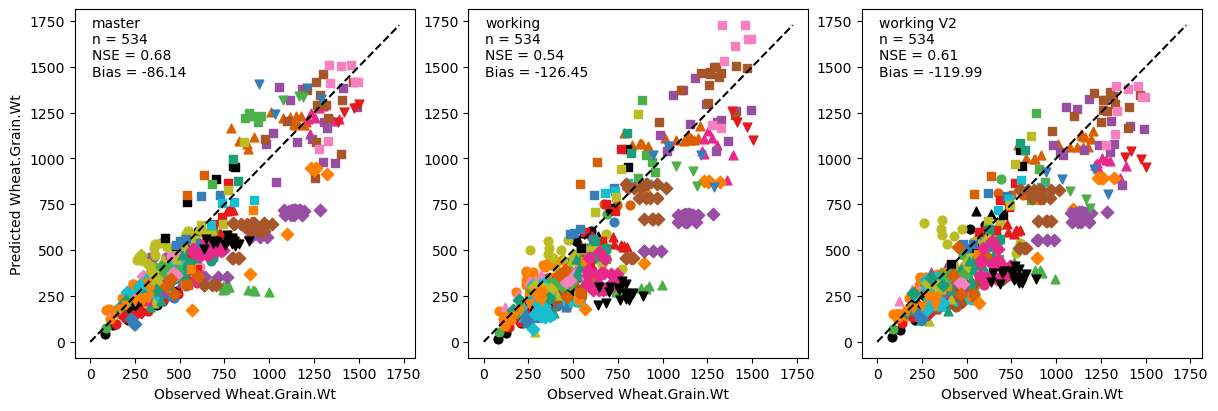

In [36]:
plot_obs_pred_by_branch("Wheat.Grain.Wt",demark_by='Experiment',mode='harvest')

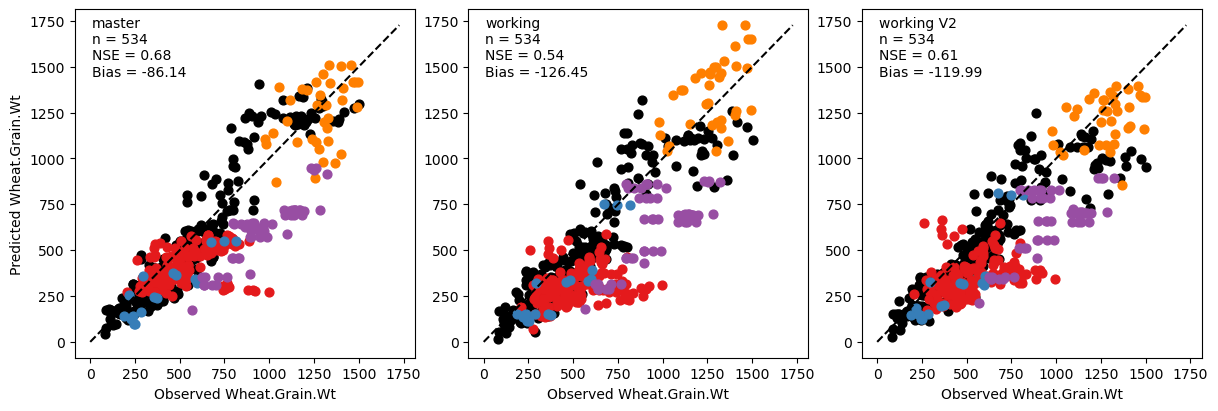

In [37]:
plot_obs_pred_by_branch("Wheat.Grain.Wt",demark_by='ProjectGroup',mode='harvest')

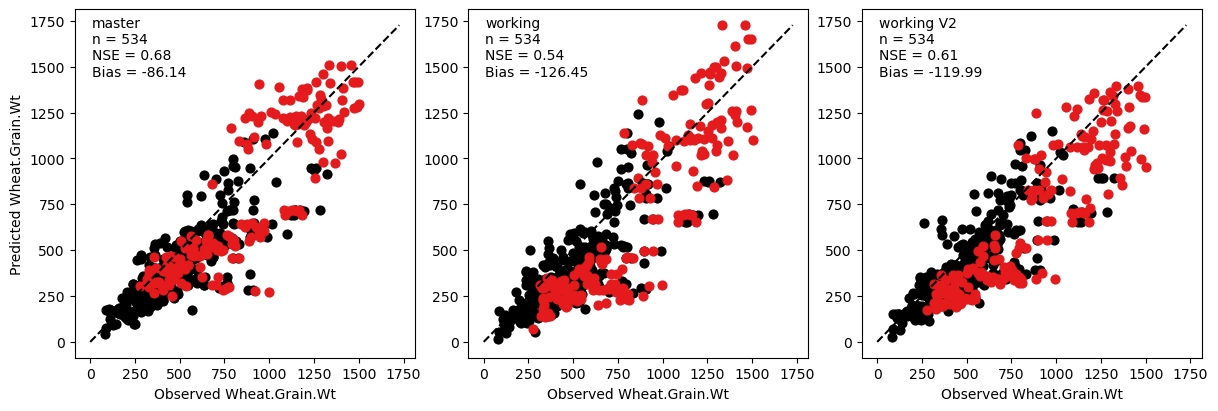

In [38]:
plot_obs_pred_by_branch("Wheat.Grain.Wt",demark_by='DevelopmentType',mode='harvest')

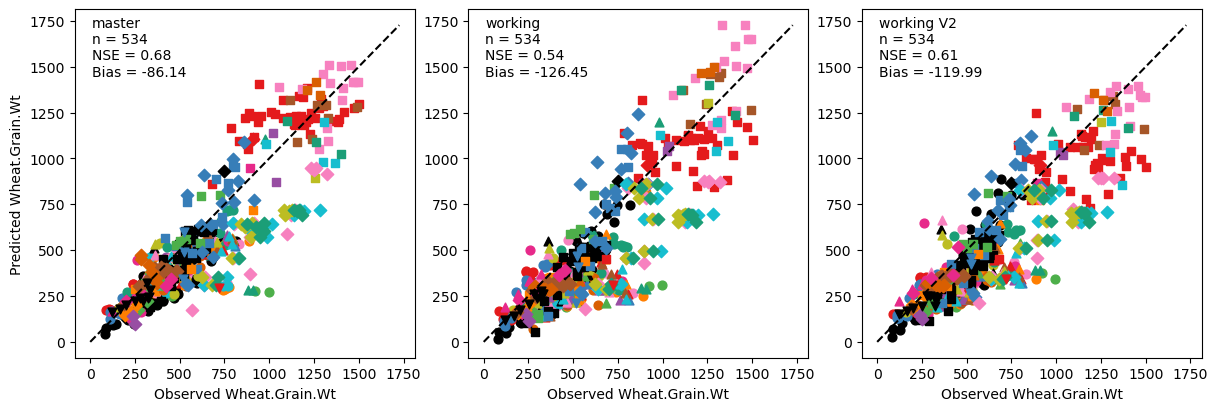

In [39]:
plot_obs_pred_by_branch("Wheat.Grain.Wt",demark_by='Wheat.SowingData.Cultivar',mode='harvest')

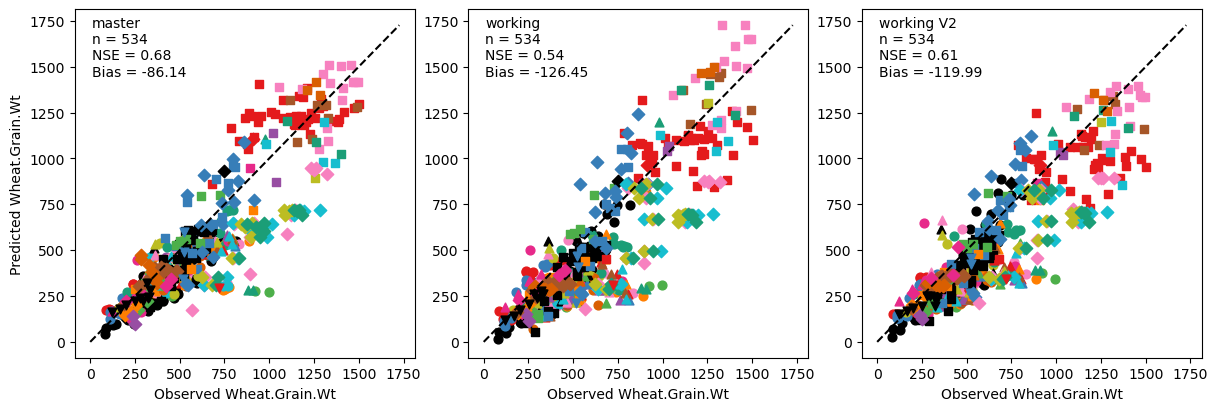

In [40]:
plot_obs_pred_by_branch("Wheat.Grain.Wt",demark_by='Wheat.SowingData.Cultivar',mode='harvest')

# Daily

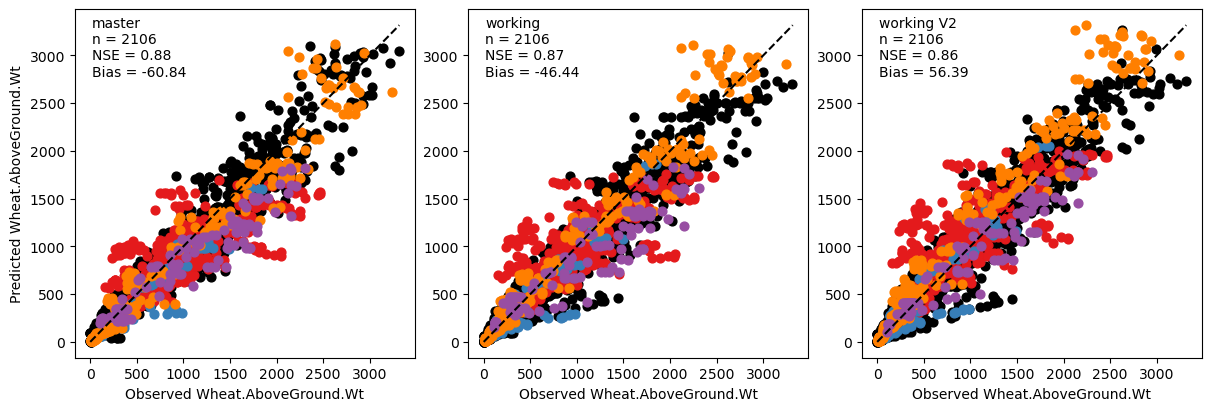

In [41]:
plot_obs_pred_by_branch("Wheat.AboveGround.Wt",demark_by='ProjectGroup')

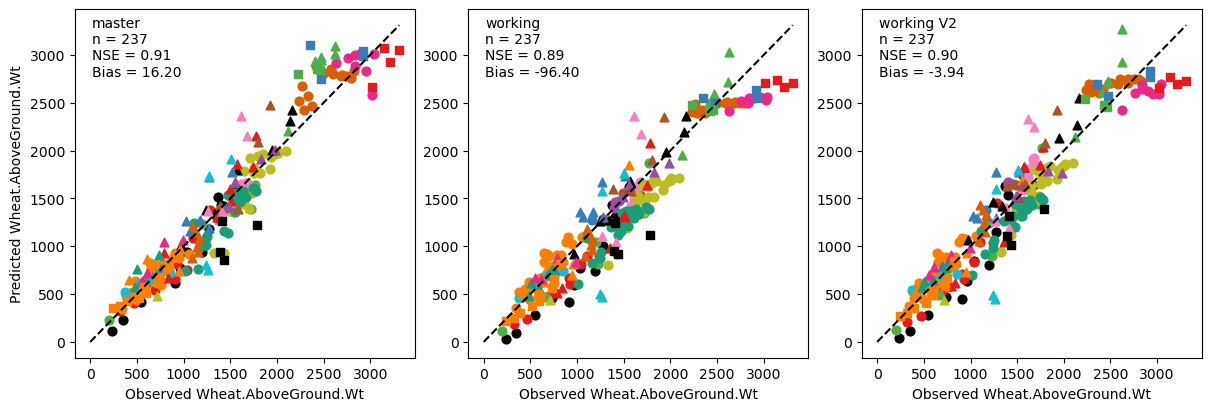

In [42]:
plot_obs_pred_by_branch("Wheat.AboveGround.Wt",demark_by='Experiment',
                       filter_dict = {'filter_fn':lambda df: df["ProjectGroup"] == "TestSet", 
                                      'filter_vars' : ["ProjectGroup"]},
                       mode='harvest')

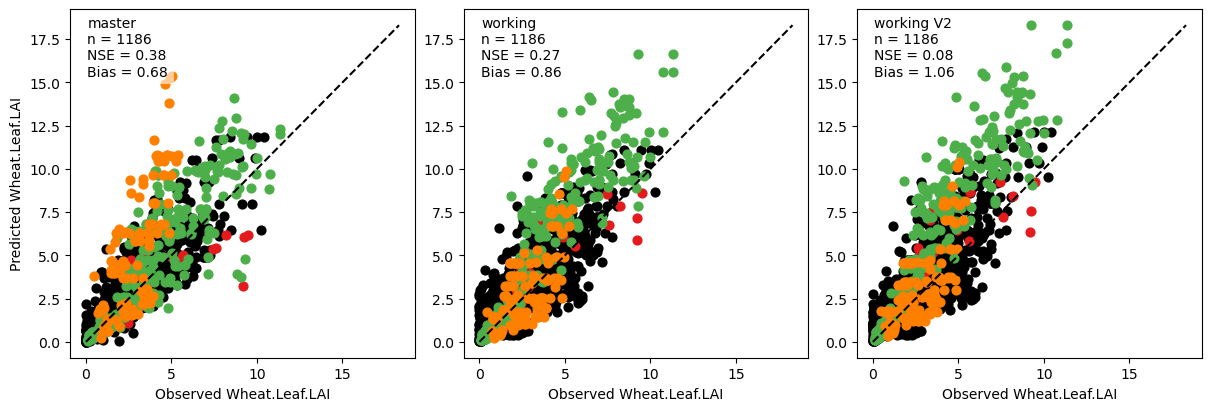

In [43]:
plot_obs_pred_by_branch("Wheat.Leaf.LAI",demark_by='ProjectGroup')